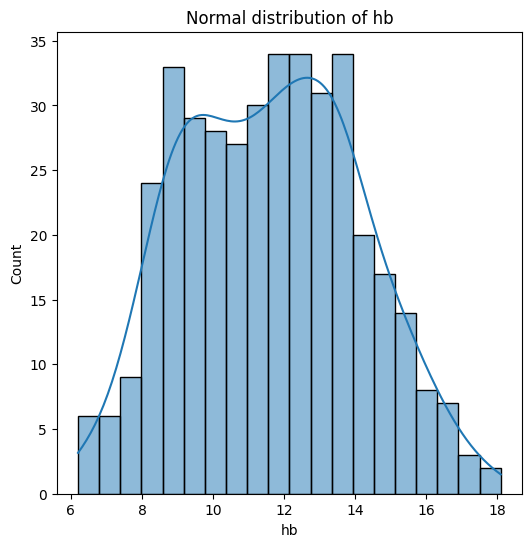

lower_bound : 9.157658791244717 upper_bound : 14.113553329967402
Mean ± 1 standard deviation : 64.64646464646465
lower_bound : 6.679711521883377 upper_bound : 16.591500599328743
Mean ± 2 standard deviation : 96.21212121212122
lower_bound : -3.2320775555619896 upper_bound : 26.50328967677411
Mean ± 3 standard deviation : 100.0
hb_zscore : 0      0.873462
1      0.994530
2      1.922718
3     -1.103981
4      0.187411
         ...   
391    0.752395
392    1.963074
393    1.034886
394    0.147055
395   -0.579353
Name: hb_zscore, Length: 396, dtype: float64
extreme_cases :      age     sex               ward    hb  hb_zscore
90    84  female           داخلي يك   6.4  -2.112880
93    75    male          ICU جنرال   6.6  -2.032168
129   57    male          قلب (CCU)  17.5   2.366634
225   59    male     خون و آنكولوژي   6.2  -2.193592
229   40  female          ICU جنرال  17.2   2.245566
230   40  female          ICU جنرال  16.6   2.003430
236    6  female             كودكان   6.4  -2.112880

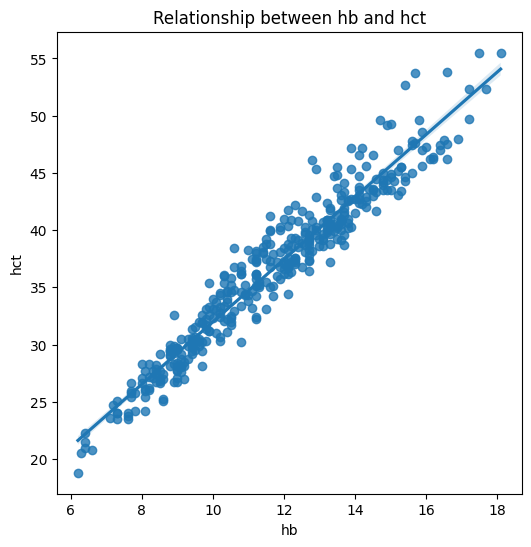

In [1]:
import pandas as pd 
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
from scipy import stats

df=pd.read_csv("CBC_blood_analys.csv")

plt.figure(figsize=(6,6))
sns.histplot(df["hb"],kde=True,bins=20)
plt.title("Normal distribution of hb")
plt.show()

mean_hb=df["hb"].mean()
std_hb=df["hb"].std()

upper_bound=mean_hb+std_hb
lower_bound=mean_hb-std_hb
print("lower_bound :",lower_bound,"upper_bound :",upper_bound)
within_range=df[(df["hb"]>=lower_bound)&(df["hb"]<=upper_bound)]
count_within=len(within_range)
total_count=len(df)
percentage=(count_within/total_count)*100
print("Mean ± 1 standard deviation :",percentage)

std_hb=std_hb*2
upper_bound=mean_hb+std_hb
lower_bound=mean_hb-std_hb
print("lower_bound :",lower_bound,"upper_bound :",upper_bound)
within_range=df[(df["hb"]>=lower_bound)&(df["hb"]<=upper_bound)]
count_within=len(within_range)
total_count=len(df)
percentage=(count_within/total_count)*100
print("Mean ± 2 standard deviation :",percentage)

std_hb=std_hb*3
upper_bound=mean_hb+std_hb
lower_bound=mean_hb-std_hb
print("lower_bound :",lower_bound,"upper_bound :",upper_bound)
within_range=df[(df["hb"]>=lower_bound)&(df["hb"]<=upper_bound)]
count_within=len(within_range)
total_count=len(df)
percentage=(count_within/total_count)*100
print("Mean ± 3 standard deviation :",percentage)

mean_hb=df["hb"].mean()
std_hb=df["hb"].std()

hb_zscore=(df["hb"]-mean_hb)/std_hb
df["hb_zscore"]=hb_zscore
print("hb_zscore :",df["hb_zscore"])

extreme_cases=df[df["hb_zscore"].abs()>2]
print("extreme_cases :",
extreme_cases[['age', 'sex', 'ward', 'hb', 'hb_zscore']])

female_hb=df[df["sex"]=="female"]["hb"]
male_hb=df[df["sex"]=="male"]["hb"]
print("ttest_pvalue :",stats.ttest_ind(female_hb,male_hb))

slope, intercept, r_value, p_value, std_err = stats.linregress(df['hb'], df['hct'])
print("slope :",slope)
print("intercept :",intercept)
print("R_squared :",r_value**2)
print("p_value :",p_value)

plt.figure(figsize=(6,6))
sns.regplot(x="hb",y="hct",data=df)
plt.title("Relationship between hb and hct")
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=17d9599a-e07d-4c50-b1b1-f0833538d301' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>